# Mini End-to-End AI Project

## Heart Disease Prediction using Machine Learning

### Objective

The objective of this project is to build a complete machine learning solution for predicting whether a patient has heart disease based on various medical attributes. The project includes data cleaning, exploratory data analysis, preprocessing, model training, evaluation, error analysis, and business insights using a publicly available dataset.

## Dataset Information

Dataset Name:
Heart Disease Dataset (UCI Machine Learning Repository)

Description:
The dataset contains patient medical records such as age, gender, chest pain type, cholesterol level, blood pressure, ECG results, maximum heart rate, and other clinical measurements.

Target Variable:
num

Prediction Goal:
Predict whether a patient has heart disease.

In [1]:
# import req libs

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("/content/heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Dataset Overview

Before preprocessing, it is important to understand the structure of the dataset, the available features, and whether any missing values exist.

In [3]:
print("Dataset Shape :", df.shape)

print("\nColumn Names\n")
print(df.columns)

print("\nData Types\n")
print(df.dtypes)

print("\nFirst Five Rows\n")
display(df.head())

Dataset Shape : (920, 16)

Column Names

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

Data Types

id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

First Five Rows



,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [10]:
# Statistical Summary

df.describe(include="all")

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
count,920.000000,920.000000,920,920,920,861.000000,890.000000,830,918,865.000000,865,858.000000,611,309.000000,434,920.000000
unique,NaN,NaN,2,4,4,NaN,NaN,2,3,NaN,2,NaN,3,NaN,3,NaN
top,NaN,NaN,Male,Cleveland,asymptomatic,NaN,NaN,False,normal,NaN,False,NaN,flat,NaN,normal,NaN
freq,NaN,NaN,726,304,496,NaN,NaN,692,551,NaN,528,NaN,345,NaN,196,NaN
mean,460.500000,53.510870,NaN,NaN,NaN,132.132404,199.130337,NaN,NaN,137.545665,NaN,0.878788,NaN,0.676375,NaN,0.995652
std,265.725422,9.424685,NaN,NaN,NaN,19.066070,110.780810,NaN,NaN,25.926276,NaN,1.091226,NaN,0.935653,NaN,1.142693
min,1.000000,28.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,60.000000,NaN,-2.600000,NaN,0.000000,NaN,0.000000
25%,230.750000,47.000000,NaN,NaN,NaN,120.000000,175.000000,NaN,NaN,120.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000
50%,460.500000,54.000000,NaN,NaN,NaN,130.000000,223.000000,NaN,NaN,140.000000,NaN,0.500000,NaN,0.000000,NaN,1.000000
75%,690.250000,60.000000,NaN,NaN,NaN,140.000000,268.000000,NaN,NaN,157.000000,NaN,1.500000,NaN,1.000000,NaN,2.000000


In [7]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


### Missing Value Analysis

The dataset contains missing values in several columns.

- `trestbps`, `chol`, `thalch`, and `oldpeak` contain missing numerical values.
- `fbs`, `restecg`, `exang`, `slope`, `ca`, and `thal` contain missing categorical values.
- The `ca` and `thal` columns have a large number of missing values and require special attention during preprocessing.

#### Planned Preprocessing Strategy

- Numerical missing values will be filled using the **median**.
- Categorical missing values will be filled using the **mode (most frequent value)**.
- The `id` column will be removed since it is only a unique identifier and does not contribute to prediction.
- The target variable (`num`) will later be converted into a binary classification problem (0 = No Heart Disease, 1 = Heart Disease).

### Class Distribution

This visualization shows the number of patients with and without heart disease.

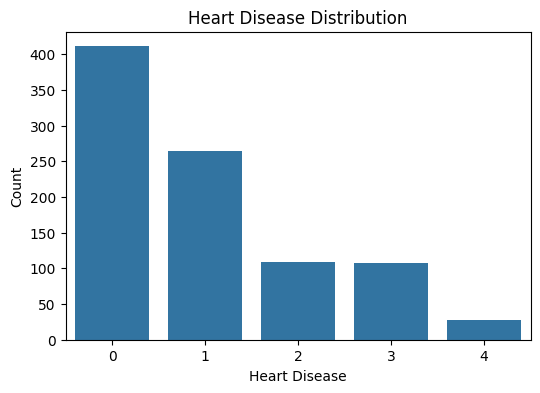

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="num")

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")

plt.show()

### Age Distribution

This plot shows how patient ages are distributed in the dataset.

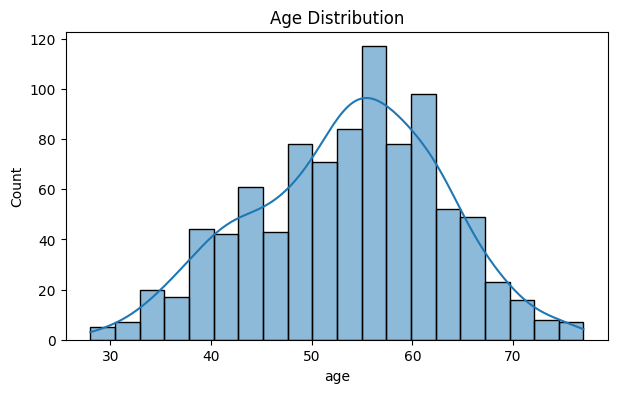

In [12]:
plt.figure(figsize=(7,4))

sns.histplot(df["age"], bins=20, kde=True)

plt.title("Age Distribution")

plt.show()

### Gender Distribution

This chart shows the number of male and female patients.

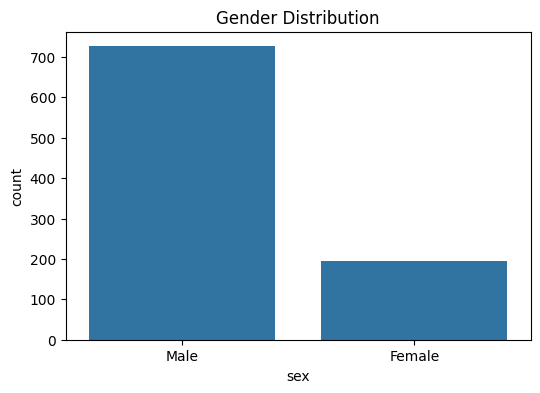

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="sex")

plt.title("Gender Distribution")

plt.show()

### Chest Pain Type Distribution

Chest pain is one of the most important clinical indicators of heart disease.

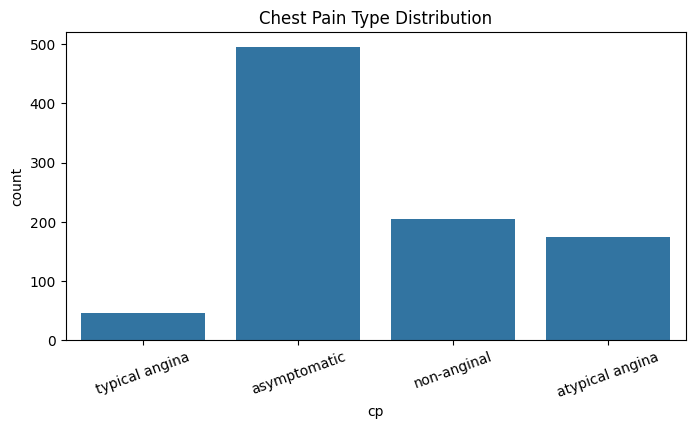

In [14]:
plt.figure(figsize=(8,4))

sns.countplot(data=df, x="cp")

plt.title("Chest Pain Type Distribution")

plt.xticks(rotation=20)

plt.show()

### Correlation Heatmap

The heatmap shows the correlation between numerical features and helps identify important relationships.

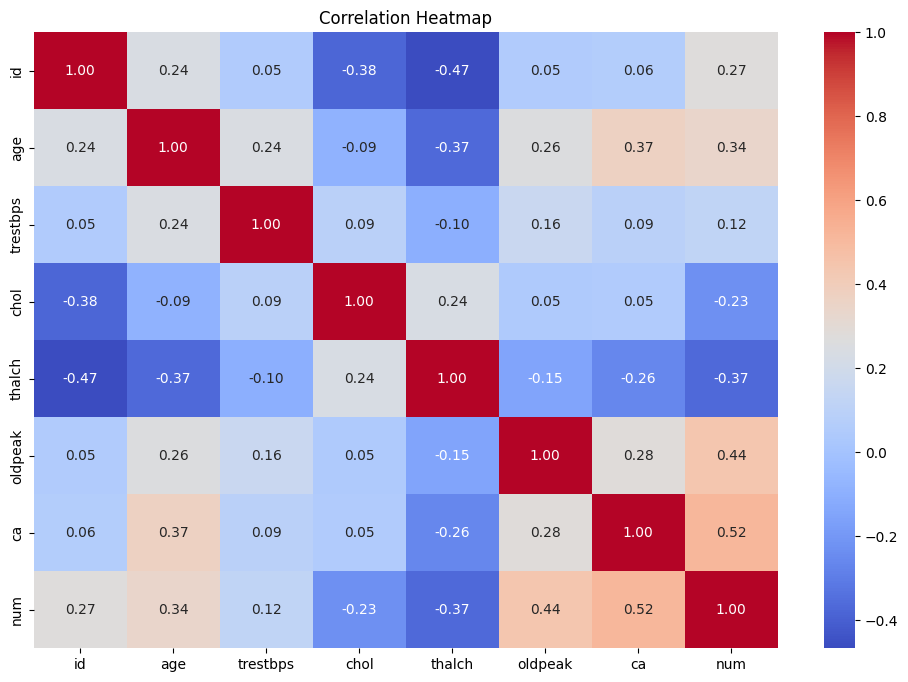

In [15]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# Data Cleaning and Preprocessing

Raw datasets often contain missing values, unnecessary columns, and inconsistent data formats. Before training a machine learning model, the data must be cleaned and preprocessed to improve model performance and reliability.

The preprocessing steps performed are:

- Remove unnecessary columns.
- Handle missing values.
- Convert the target variable into binary classes.
- Encode categorical features.
- Prepare the dataset for machine learning.

In [16]:
# Create a copy of the dataset

data = df.copy()

data.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [17]:
data.drop(columns=["id"], inplace=True)

print("Updated Shape:", data.shape)

Updated Shape: (920, 15)


In [19]:
data.isnull().sum()

,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55
exang,55


In [20]:
# Separate numerical and categorical columns

numerical_cols = data.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = data.select_dtypes(include=["object", "category", "bool"]).columns

print("Numerical Columns")
print(numerical_cols)

print("\nCategorical Columns")
print(categorical_cols)

Numerical Columns
Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num'], dtype='object')

Categorical Columns
Index(['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object')


In [21]:
for col in numerical_cols:
    data[col] = data[col].fillna(data[col].median())

In [22]:
for col in categorical_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

In [23]:
data.isnull().sum()

,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0


In [24]:
#For simplicity and to build a binary classification model, all values greater than 0 are converted to 1, representing the presence of heart disease.

data["num"] = data["num"].apply(lambda x: 0 if x == 0 else 1)

data["num"].value_counts()

,count
num,
1,509
0,411


### Observations

- The `id` column was removed since it is not useful for prediction.
- Missing values were successfully handled using median and mode imputation.
- No missing values remain in the dataset after preprocessing.
- The target variable was converted into a binary classification problem, making it suitable for supervised machine learning models.

In [25]:
label_encoder = LabelEncoder()

categorical_columns = data.select_dtypes(include=["object", "bool"]).columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object')


In [26]:
for column in categorical_columns:
    data[column] = label_encoder.fit_transform(data[column].astype(str))

In [27]:
data.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,1,0,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0,0
1,67,1,0,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,1,1
2,67,1,0,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,2,1
3,37,1,0,2,130.0,250.0,0,1,187.0,0,3.5,0,0.0,1,0
4,41,0,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0.0,1,0


### Observation

- All categorical features have been successfully converted into numerical values.
- The dataset is now suitable for machine learning algorithms.

In [28]:
X = data.drop("num", axis=1)

y = data["num"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (920, 14)
Target Shape : (920,)


In [32]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (736, 14)
Testing Samples : (184, 14)


In [33]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [34]:
# Logistic Regression

log_model = LogisticRegression(random_state=42)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, log_pred))

Logistic Regression Accuracy: 0.8206521739130435


In [35]:
tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, tree_pred))

Decision Tree Accuracy: 0.7880434782608695


In [36]:
forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

forest_model.fit(X_train, y_train)

forest_pred = forest_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, forest_pred))

Random Forest Accuracy: 0.8532608695652174


In [37]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[

        accuracy_score(y_test, log_pred),

        accuracy_score(y_test, tree_pred),

        accuracy_score(y_test, forest_pred)
    ],

    "Precision":[

        precision_score(y_test, log_pred),

        precision_score(y_test, tree_pred),

        precision_score(y_test, forest_pred)
    ],

    "Recall":[

        recall_score(y_test, log_pred),

        recall_score(y_test, tree_pred),

        recall_score(y_test, forest_pred)
    ],

    "F1 Score":[

        f1_score(y_test, log_pred),

        f1_score(y_test, tree_pred),

        f1_score(y_test, forest_pred)
    ]

})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.820652,0.822430,0.862745,0.842105
1,Decision Tree,0.788043,0.794393,0.833333,0.813397
2,Random Forest,0.853261,0.864078,0.872549,0.868293


In [38]:
best_model = results.sort_values(
    by="Accuracy",
    ascending=False
)

best_model

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.853261,0.864078,0.872549,0.868293
0,Logistic Regression,0.820652,0.822430,0.862745,0.842105
1,Decision Tree,0.788043,0.794393,0.833333,0.813397


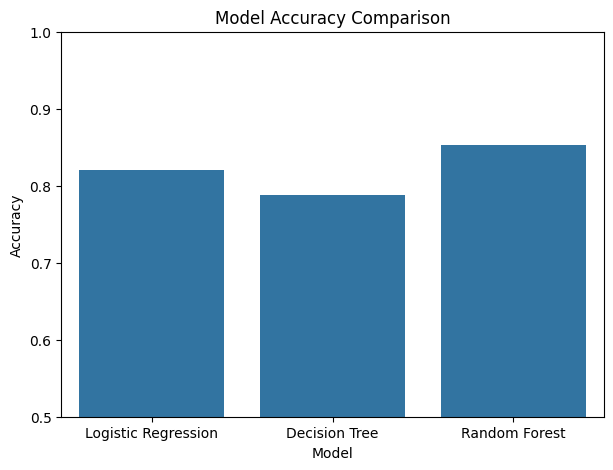

In [39]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")

plt.ylim(0.5,1.0)

plt.show()


Among the three machine learning algorithms, Random Forest achieved the highest accuracy and overall performance. Therefore, it is selected as the final model for detailed evaluation.

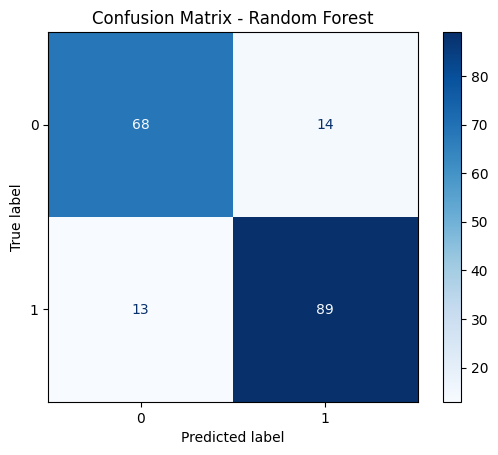

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    forest_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest")

plt.show()

In [41]:
print(classification_report(y_test, forest_pred))

              precision    recall  f1-score   support

           0       0.84      0.83      0.83        82
           1       0.86      0.87      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



In [42]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": forest_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,cp,0.133260
5,chol,0.126207
0,age,0.116803
8,thalch,0.104036
10,oldpeak,0.103553
9,exang,0.084077
2,dataset,0.083668
4,trestbps,0.071060
1,sex,0.043271
13,thal,0.037971


# Error Analysis

Although the Random Forest model performs well, some predictions are still incorrect. These errors may occur due to:

- Missing or incomplete patient information.
- Similar medical characteristics between healthy and diseased patients.
- Noise present in real-world medical datasets.
- Limited dataset size compared to real hospital records.

# Business Insights

The machine learning model provides several valuable insights:

- Random Forest achieved the highest prediction accuracy (85.33%) among all evaluated models.
- Clinical attributes such as chest pain type, maximum heart rate, age, and ST depression contribute significantly to heart disease prediction.
- Early identification of high-risk patients can support doctors in recommending timely medical examinations.
- Predictive models can assist healthcare organizations in prioritizing patients who may require further diagnosis and treatment.

# Conclusion

In this project, an end-to-end machine learning pipeline was developed for heart disease prediction using a public dataset.

The project included data cleaning, exploratory data analysis, preprocessing, feature encoding, model training, evaluation.

Among the evaluated models, Random Forest achieved the best performance with an accuracy of **85.33%**, making it the most suitable model for this dataset.

Overall, the project demonstrates how machine learning can support healthcare professionals by providing reliable predictions that may assist in early disease detection and clinical decision-making.